In [2]:
import sys
import datetime as dt
import pandas as pd
import numpy as np
from pathlib import Path

sys.path.append(str(Path.cwd().parent)) 

from data.resampled_data_loader import get_resampled_quotes

instruments = ['USDSGD', 'EURUSD', 'AUDUSD', 'GBPUSD', 'USDJPY']
ccys = ['USD', 'EUR', 'AUD', 'GBP', 'JPY']

start_date = dt.datetime(2020, 1, 1)
end_date = dt.datetime(2025, 12, 31)
freq = pd.Timedelta(minutes=15)

prices = get_resampled_quotes(instruments, start_date, end_date, freq)

In [3]:
def regression_stats(x, y):
    sample = pd.concat({"x": x, "y": y}, axis=1).dropna()
    if len(sample) < 3 or sample["x"].var() == 0 or sample["y"].var() == 0:
        return np.nan, np.nan, len(sample)

    beta = sample["y"].cov(sample["x"]) / sample["x"].var()
    corr = sample["x"].corr(sample["y"])
    return beta, corr, len(sample)

In [ ]:
def sharpe(pnl_series : pd.Series):
    daily_pnl_series = pnl_series.resample("1D").sum()

    return daily_pnl_series.mean() / daily_pnl_series.std() * np.sqrt(252)

In [4]:
import importlib
import strategy.sgd_neer_strategy as sn

importlib.reload(sn)
from strategy.sgd_neer_strategy import SGDNEERStrategy

strategy = SGDNEERStrategy(instruments, prices,
                        {
                            "rolling_window" : pd.Timedelta(minutes=15),
                            "zscore_window" : pd.Timedelta(hours=3),
                            "zscore_entry_threshold" : 2.0,
                            "zscore_exit_threshold" : 0.0,
                            "spread_entry_multiplier" : 5.0
                        })


In [8]:
ret_series = strategy.build_rets_vs_sgd()["index"]

<Axes: xlabel='interval_seconds'>

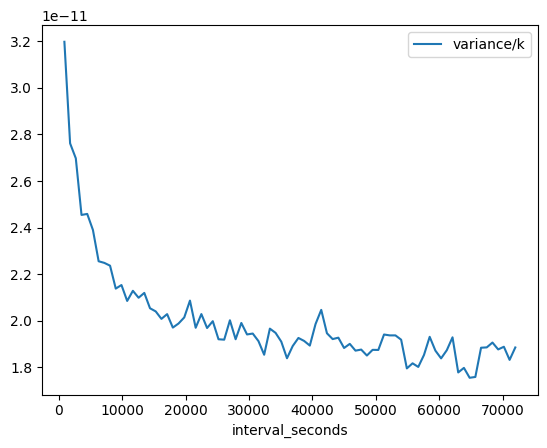

In [10]:
import mean_reversion as mv

importlib.reload(mv)
from mean_reversion import variance_ratio, return_regression_heatmap, return_regression, apply_position

variance_ratio(ret_series, pd.Timedelta(seconds=72000)).plot()

In [ ]:
return_regression_heatmap(ret_series, pd.Timedelta(hours=3), pd.Timedelta(hours=1))

In [ ]:
import itertools


def sweep_parameters(
    df_base,
    tcost_bps=1.0,
    margin_multiples=np.arange(0.0, 1.0, 0.1),
    adjust_to_target_values=[True, False],
    pred_zs_thresholds=np.arange(0.0, 2.0, 0.2),
):
    result = []

    for margin_multiple, adjust_to_target, pred_zs_threshold in itertools.product(
        margin_multiples, adjust_to_target_values, pred_zs_thresholds
    ):
        df = df_base.copy()
        df = apply_position(
            df,
            tcost_bps=tcost_bps,
            margin_multiple=margin_multiple,
            adjust_to_target=adjust_to_target,
            pred_zs_threshold=pred_zs_threshold,
        )

        df["gross_pnl"] = df["position"] * df["ret"]
        df["net_pnl"] = (
            df["gross_pnl"] - 0.5 * df["tcost"] * df["position"].diff().abs()
        )

        periods_per_year = pd.Timedelta(days=365) / freq
        
        result.append(
            {
                "margin_multiple": margin_multiple,
                "adjust_to_target_value": adjust_to_target,
                "pred_zs_threshold": pred_zs_threshold,
                "net_sharpe": sharpe(df["gross_pnl"], periods_per_year=252 * 6.5 * 4),
            }
        )

In [4]:
signals = strategy.generate_signals()

In [315]:
from trading.aggressive_trader import AggressiveTrader
from analytics.performance_report import PerformanceReport

trader = AggressiveTrader(instruments, prices, signals)

report = PerformanceReport(instruments, trader)

report.generate_performance_report()

,Sharpe_Net,Sharpe_Gross,AvgTradesPerDay,MaxDrawdown,WorstDayPnL,AvgNetPnLPerTrade,AvgGrossPnLPerTrade,AvgPosDur,MedPosDur,Q10PosDur,Q90PosDur
USDSGD,-5.487556,0.163017,2.764384,-1.016669,-0.016092,-0.000168,0.000004,0 days 00:27:31.068652,0 days 00:15:00,0 days 00:15:00,0 days 00:45:00
EURUSD,0.352375,0.84972,1.215525,-0.03093,-0.006909,0.000013,0.000031,0 days 00:25:12.622088,0 days 00:15:00,0 days 00:15:00,0 days 00:45:00
AUDUSD,-0.385659,0.247508,0.244261,-0.03693,-0.007253,-0.000053,0.000034,0 days 00:23:13.984962,0 days 00:15:00,0 days 00:15:00,0 days 00:45:00
GBPUSD,-0.345433,0.176559,0.556164,-0.045079,-0.008753,-0.000027,0.000014,0 days 00:25:00,0 days 00:15:00,0 days 00:15:00,0 days 00:45:00
USDJPY,-0.689247,-0.078876,1.735952,-0.133903,-0.015044,-0.000025,-0.000003,0 days 00:29:40.105263,0 days 00:15:00,0 days 00:15:00,0 days 00:45:00


<Axes: title={'center': 'EURUSD Cumulative PnL'}, xlabel='Time', ylabel='Cumulative PnL'>

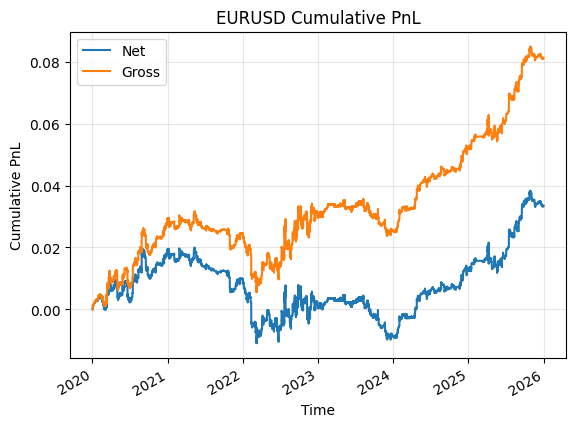

In [316]:
report.plot_cumulative_pnl('EURUSD')

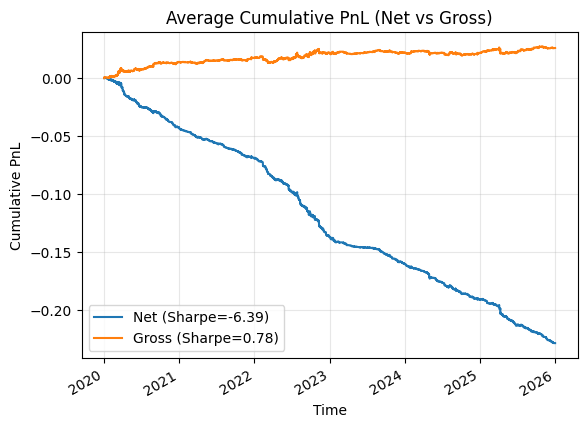

In [317]:
import numpy as np

freq_mult = pd.Timedelta(days=1) / freq

net_pnl_dict = trader.generate_net_pnl()
gross_pnl_dict = trader.generate_gross_pnl()

net_df = pd.DataFrame(net_pnl_dict).fillna(0.0)
gross_df = pd.DataFrame(gross_pnl_dict).fillna(0.0)

avg_net = net_df.mean(axis=1)
avg_gross = gross_df.mean(axis=1)

net_sharpe = np.sqrt(252 * freq_mult) * avg_net.mean() / avg_net.std() if avg_net.std() != 0 else np.nan
gross_sharpe = (
    np.sqrt(252 * freq_mult) * avg_gross.mean() / avg_gross.std() if avg_gross.std() != 0 else np.nan
)

ax = avg_net.cumsum().plot(label=f"Net (Sharpe={net_sharpe:.2f})")
avg_gross.cumsum().plot(ax=ax, label=f"Gross (Sharpe={gross_sharpe:.2f})")

ax.set_title("Average Cumulative PnL (Net vs Gross)")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.grid(True, alpha=0.3)


In [307]:
rets_vs_sgd = strategy.build_rets_vs_sgd()

In [296]:
rolling_windows_mins = [15, 30, 60, 120]
fwd_periods_mins = [15, 30, 60]

zscore_window_mins = 120

bar_minutes = int(freq / pd.Timedelta(minutes=1))

rolling_windows = [x // bar_minutes for x in rolling_windows_mins]
fwd_periods = [x // bar_minutes for x in fwd_periods_mins]
zscore_window = zscore_window_mins // bar_minutes

zscore_bins = [
    (0, 0.5),
    (0.5, 1),
    (1, 2),
    (2, np.inf),
]

results = []

for rolling_window_mins, rolling_window in zip(rolling_windows_mins, rolling_windows):
    for fwd_period_mins, fwd_period in zip(fwd_periods_mins, fwd_periods):
        for ccy in ccys + ["index"]:
            past_ret = rets_vs_sgd[ccy].rolling(rolling_window).sum()

            past_z = (
                (past_ret - past_ret.rolling(zscore_window).mean())
                / past_ret.rolling(zscore_window).std()
            )

            future_ccy_ret = (
                rets_vs_sgd[ccy]
                .rolling(fwd_period)
                .sum()
                .shift(-fwd_period)
            )

            abs_z = past_z.abs()

            for lower, upper in zscore_bins:
                if np.isinf(upper):
                    bucket_mask = abs_z > lower
                    z_bucket = f">{lower}"
                else:
                    bucket_mask = (abs_z >= lower) & (abs_z < upper)
                    z_bucket = f"{lower}-{upper}"

                beta, corr, n_obs = regression_stats(
                    past_ret[bucket_mask],
                    future_ccy_ret[bucket_mask],
                )

                results.append({
                    "ccy": ccy,
                    "rolling_window_mins": rolling_window_mins,
                    "fwd_period_mins": fwd_period_mins,
                    "zscore_window_mins": zscore_window_mins,
                    "z_bucket": z_bucket,
                    "beta": beta,
                    "corr": corr,
                    "n_obs": n_obs,
                })

zscore_bucket_results = pd.DataFrame(results)

zscore_bucket_results.sort_values(
    ["rolling_window_mins", "fwd_period_mins", "ccy", "z_bucket"]
)


,ccy,rolling_window_mins,fwd_period_mins,zscore_window_mins,z_bucket,beta,corr,n_obs
8,AUD,15,15,120,0-0.5,-0.047006,-0.020755,54742
9,AUD,15,15,120,0.5-1,-0.019577,-0.015166,42884
10,AUD,15,15,120,1-2,-0.038900,-0.052278,40320
11,AUD,15,15,120,>2,-0.044356,-0.097613,3286
4,EUR,15,15,120,0-0.5,-0.089790,-0.039128,55306
...,...,...,...,...,...,...,...,...
267,USD,120,60,120,>2,-0.042137,-0.064407,5329
284,index,120,60,120,0-0.5,-0.038961,-0.042630,36330
285,index,120,60,120,0.5-1,-0.060156,-0.075431,39158
286,index,120,60,120,1-2,-0.081605,-0.119970,60723


In [222]:
zscore_bucket_results.pivot_table(
    index=["rolling_window_mins", "fwd_period_mins", "ccy"],
    columns="z_bucket",
    values="corr",
).to_clipboard()


In [78]:
rets_vs_sgd.columns.to_list()

['index', 'USD', 'EUR', 'JPY', 'AUD', 'GBP', 'HKD']

<Axes: xlabel='timestamp'>

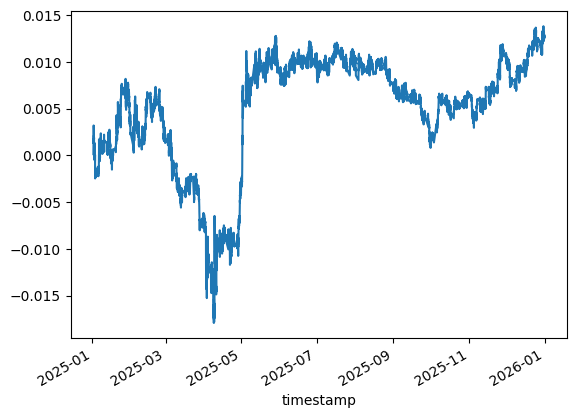

In [ ]:
rets['index'].cumsum().plot()

<Axes: xlabel='timestamp'>

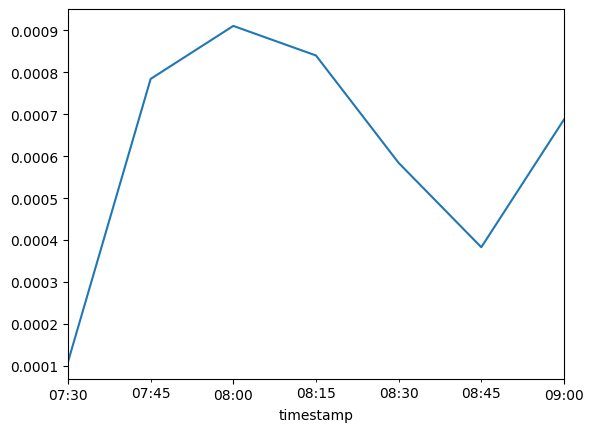

In [13]:
rets.loc['2025-07-03 07:30' : '2025-07-03 09:00']['index'].cumsum().plot()

In [91]:
rolling_windows_mins = 15
fwd_periods_mins = 15
zscore_window_mins = 120
bar_minutes = int(freq / pd.Timedelta(minutes=1))

rolling_windows = rolling_windows_mins // bar_minutes
fwd_periods = fwd_periods_mins // bar_minutes
zscore_window = zscore_window_mins // bar_minutes

results = rets_vs_sgd.copy()

for ccy in ccys + ["index"]:

    past_ret = rets_vs_sgd[ccy].rolling(rolling_window).sum()
    past_relative_ret = (rets_vs_sgd[ccy] - rets_vs_sgd["index"]).rolling(rolling_window).sum()

    past_z = (
        (past_ret - past_ret.rolling(zscore_window).mean())
        / past_ret.rolling(zscore_window).std()
    )

    past_relative_z = (
        (past_relative_ret - past_relative_ret.rolling(zscore_window).mean())
        / past_relative_ret.rolling(zscore_window).std()
    )

    future_ccy_ret = (
        rets_vs_sgd[ccy]
        .rolling(fwd_period)
        .sum()
        .shift(-fwd_period)
    )

    results[ccy + "_past_ret"] = past_ret
    results[ccy + "_past_z"] = past_z
    results[ccy + "_past_relative_ret"] = past_relative_ret
    results[ccy + "_past_relative_z"] = past_relative_z

In [100]:
zs_mask = results["index_past_z"].abs() > 2.0
results[zs_mask].filter(like="_z").to_clipboard()

In [98]:
results.filter(like="past_z").to_clipboard()